### AI-Powered Movie Recommendation System

A recommendation system built on the MovieLens dataset, combining
**content-based filtering** (genre similarity) and **collaborative
filtering** (user-rating similarity), enriched with metadata from the
TMDb API.

**Notebook structure:** Imports → Config → Load Data → EDA → Preprocessing
→ Feature Engineering → Modeling → Evaluation → Conclusions.


### Imports

Standard data analysis stack, plus `scipy` for the similarity/statistical
methods this assignment specifically calls for (`scipy.spatial.distance`,
`scipy.stats`), and `requests` for the TMDb API enrichment step.


In [11]:
import json
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy.cluster.vq import kmeans, vq, whiten
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr

### Config / Constants

Centralizing paths and constants here (rather than scattering literals
through the notebook) keeps the rest of the analysis readable and makes
it trivial to point at a different data location later.


In [ ]:
RANDOM_STATE = 42  # reused anywhere sampling/ordering could vary, for reproducibility
DATA_DIR = Path("../data")
MOVIES_PATH = DATA_DIR / "movies.csv"
RATINGS_PATH = DATA_DIR / "ratings.csv"

# Consistent palette used across every chart
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)

### Load Data

Loading the two MovieLens CSVs. See the README for how to obtain these -
they're gitignored and expected directly under `data/`.


In [3]:
try:
    movies = pd.read_csv(MOVIES_PATH)
    ratings = pd.read_csv(RATINGS_PATH)
except FileNotFoundError as e:
    raise FileNotFoundError(
        "Expected movies.csv and ratings.csv directly under data/. "
        "See the README's 'Get the dataset' step."
    ) from e

print(f"movies: {movies.shape}")
print(f"ratings: {ratings.shape}")

movies: (62423, 3)
ratings: (25000095, 4)


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


### Inspect / EDA

Before touching the data, profile it: shape, dtypes, nulls, duplicates, and basic distributions. This surfaces data-quality issues up front rather than discovering them mid-pipeline.


In [ ]:
for name, df in [("movies", movies), ("ratings", ratings)]:
    print(f"--- {name} ---")
    print(df.dtypes)
    print(f"Nulls:\n{df.isnull().sum()}")
    print(f"Duplicate rows: {df.duplicated().sum()}")

--- movies ---
movieId    int64
title        str
genres       str
dtype: object
Nulls:
movieId    0
title      0
genres     0
dtype: int64
Duplicate rows: 0
--- ratings ---
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object
Nulls:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Duplicate rows: 0


No nulls found in this dataset


In [ ]:
ratings["rating"].describe()

count    2.500010e+07
mean     3.533854e+00
std      1.060744e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

### Rating Distribution

Ratings are bounded to 10 fixed values (0.5 - 5.0 in 0.5 steps), so a standard IQR outlier check doesn't apply. Every value in range is a valid rating by construction. Instead, we check the _shape_ of the distribution for rating inflation: `describe()` already showed a mean below 4.0 (3.54) but above the midpoint (3.0) of the scale, suggesting most users rate movies they liked rather than rating uniformly across the full range.


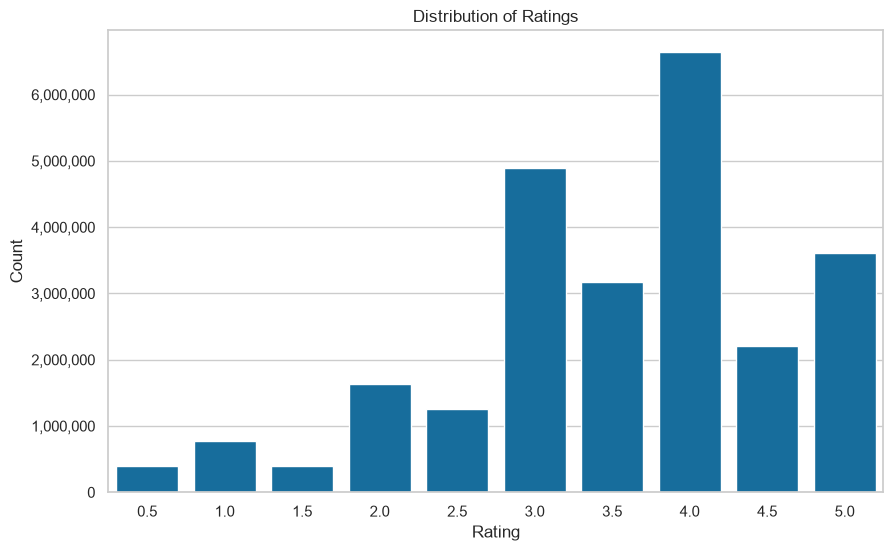

In [13]:
sns.countplot(x=ratings["rating"])
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y):,}"))
plt.show()

Ratings are heavily skewed towards the positive end:
4.0 is the most common rating (~6.5M out of total 25M which is ~26%), and ratings of 3.5 and above account for roughly 63% of all ratings. This is most likely 'rating inflation', which means that users are more likely to rate movies they actively liked than one they disliked or abandoned, so the observed distribution overrepresents positive experiences relative to true audience opinion. This matters for later modeling, where a raw average rating is a biased signal of movie quality, not just popularity.


In [15]:
movies["genres"].value_counts()

genres
Drama                                       9056
Comedy                                      5674
(no genres listed)                          5062
Documentary                                 4731
Comedy|Drama                                2386
                                            ... 
Animation|Children|Comedy|Fantasy|Horror       1
Comedy|Drama|Fantasy|War                       1
Children|Comedy|Fantasy|Mystery                1
Children|Comedy|Crime|Fantasy                  1
Comedy|Horror|Mystery|Sci-Fi|Western           1
Name: count, Length: 1639, dtype: int64

### Genre Distribution

`genres` has 0 nulls per `isnull()`, but a genre split reveals a hidden missing-value case:
5,062 of 62,423 movies have a "(no genres listed)" value instead of real genre data. Rather than filtering it silently, it is kept as its own bar below and labeled here explicitly, since dropping it would understate how much genre metadata is actually missing from this dataset.


In [ ]:
genre_counts = movies["genres"].str.split("|").explode().value_counts()

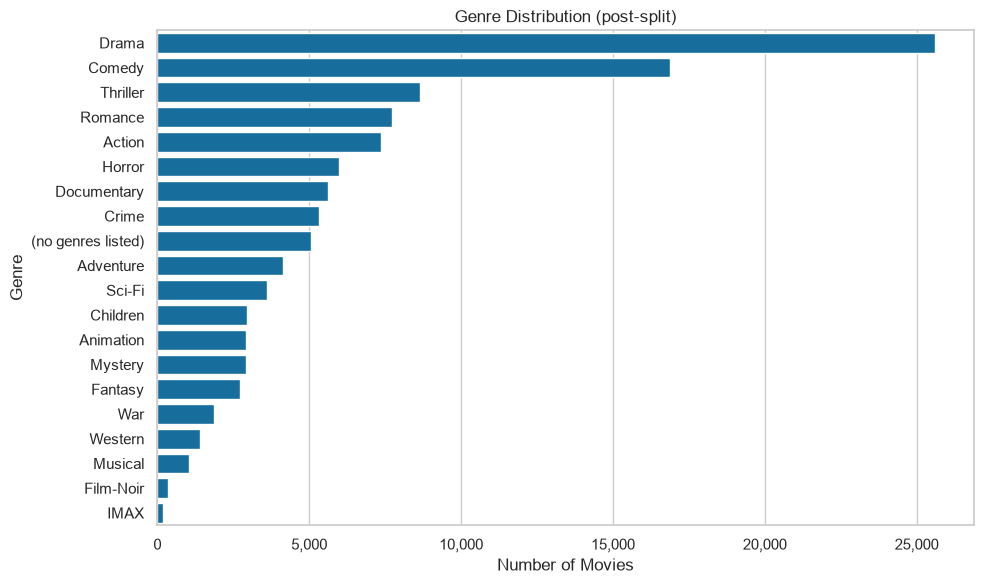

In [ ]:
sns.barplot(x=genre_counts.values, y=genre_counts.index, orient="h")
plt.title("Genre Distribution (post-split)")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

Note: genres aren't mutually exclusive. A movie tagged `Horror|Thriller` counts towards both bars, so this chart shows how often each genre appears, not a partition of movies into single categories.


### Ratings per Movie / Ratings per User


In [ ]:
ratings_per_movie = ratings.groupby("movieId").size()
ratings_per_user = ratings.groupby("userId").size()

In [22]:
ratings_per_movie.describe()

count    59047.000000
mean       423.393144
std       2477.885821
min          1.000000
25%          2.000000
50%          6.000000
75%         36.000000
max      81491.000000
dtype: float64

In [23]:
ratings_per_user.describe()

count    162541.000000
mean        153.807932
std         268.047590
min          20.000000
25%          36.000000
50%          71.000000
75%         162.000000
max       32202.000000
dtype: float64

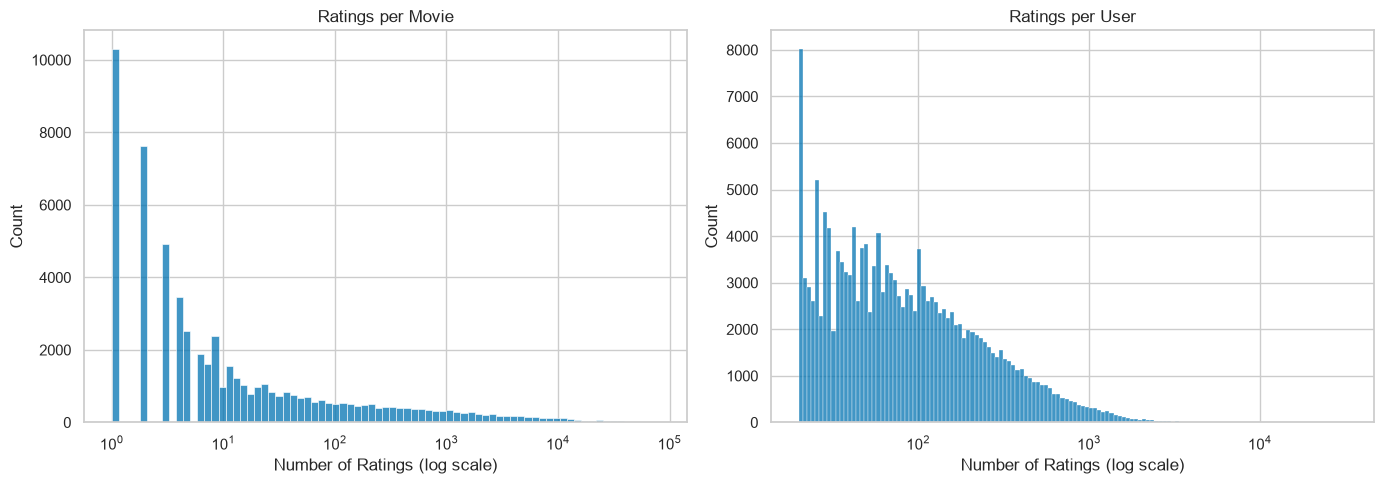

In [ ]:
fix, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(ratings_per_movie, log_scale=True, ax=axes[0])
axes[0].set_title("Ratings per Movie")
axes[0].set_xlabel("Number of Ratings (log scale)")

sns.histplot(ratings_per_user, log_scale=True, ax=axes[1])
axes[1].set_title("Ratings per User")
axes[1].set_xlabel("Number of Ratings (log scale)")

plt.tight_layout()
plt.show()

Median ratings-per-movie is 6, but the mean is 423. A handful of blockbuster movies account for a disproportionate share of all ratings. Ratings-per-user has a similar mean / median gap (71 vs. 154), though it is bounded below at exactly 20. The MovieLens dataset is curated to only include users with > 20 ratings. Given the extreme skew, both are plotted on a log-scaled x-axis.


### User-Item Matrix Sparsity


In [25]:
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)

sparsity = 1 - (n_ratings / (n_users * n_movies))
print(f"Users: {n_users:,} | Movies: {n_movies:,} | Ratings: {n_ratings:,}")
print(f"Sparsity: {sparsity:.4%}")

Users: 162,541 | Movies: 59,047 | Ratings: 25,000,095
Sparsity: 99.7395%


A full user-item rating matrix would have ~9.6 billion cells (162,541 users x 59,047 movies), but only 25,000,095 are actually filled in. That's 99.74% empty. This matters for the recommendation engine because collaborative filtering works by comparing rating patterns between users (or movies) to find similarity (e.g 'users who rated this set of movies similarly to you also liked X'). That only works when there's enough overlap in what's actually been rated. At 99.74% empty, most pairs of users share almost no commonly-rated movies to compare, and most movies don't have enough raters to find a reliable pattern at all.


### Preprocessing: Timestamp to Datetime

Converting to a real datetime unlocks year / month-level grouping for any time-based analysis.


In [ ]:
ratings["rated_at"] = pd.to_datetime(ratings["timestamp"], unit="s").dt.normalize()
ratings = ratings.drop(columns="timestamp")

In [44]:
ratings.head()

,userId,movieId,rating,rated_at
0,1,296,5.0,2006-05-17
1,1,306,3.5,2006-05-17
2,1,307,5.0,2006-05-17
3,1,665,5.0,2006-05-17
4,1,899,3.5,2006-05-17


### Rating Volume Over Time


In [ ]:
ratings_per_year = ratings["rated_at"].dt.year.value_counts().sort_index()

In [46]:
ratings_per_year

rated_at
1995          3
1996    1430093
1997     626202
1998     272099
1999    1059080
2000    1735398
2001    1058750
2002     776654
2003     920295
2004    1048116
2005    1613550
2006    1038458
2007     931432
2008    1018001
2009     810127
2010     792436
2011     676498
2012     635208
2013     515684
2014     478270
2015    1604971
2016    1757440
2017    1689935
2018    1310761
2019    1200634
Name: count, dtype: int64

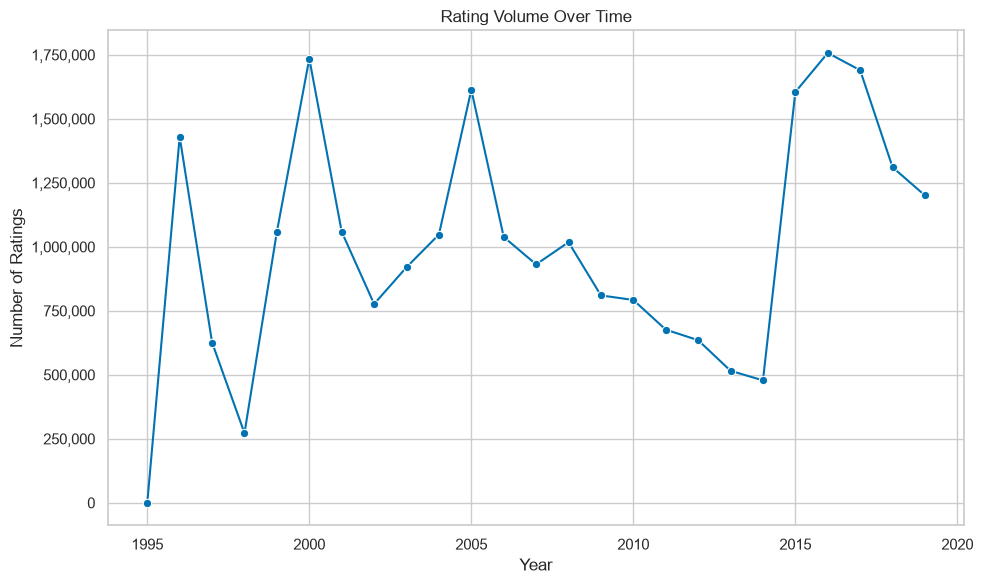

In [ ]:
sns.lineplot(x=ratings_per_year.index, y=ratings_per_year.values, marker="o")
plt.title("Rating Volume Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y):,}"))
plt.tight_layout()
plt.show()